In [5]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.shape)
print(df.head())
print(df['label'].value_counts())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
print("New shape:", df.shape)

label      0
message    0
dtype: int64
Duplicates: 403
New shape: (5169, 2)


In [8]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [9]:
df['message_length'] = df['message'].apply(len)

print(df.groupby('label')['message_length'].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


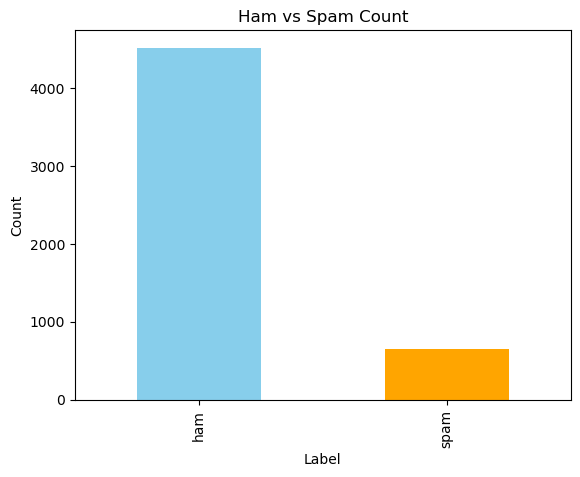

In [10]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Ham vs Spam Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9661508704061895

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034


Confusion Matrix:
 [[902   1]
 [ 34  97]]


In [16]:
sample_msgs = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting for dinner tonight?",
    "Free entry into our weekly competition, text WIN now",
    "Can you send me the notes from class?",
    "can we win this prize together and get a free ticket to germany?"
]

preds = model.predict(sample_msgs)

for msg, pred in zip(sample_msgs, preds):
    print(msg, "->", "spam" if pred == 1 else "ham")

Congratulations! You have won a free prize. Call now! -> spam
Hey, are we still meeting for dinner tonight? -> ham
Free entry into our weekly competition, text WIN now -> spam
Can you send me the notes from class? -> ham
can we win this prize together and get a free ticket to germany? -> spam


In [17]:
!pip install streamlit


In [1]:
import pickle

with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

NameError: name 'model' is not defined

In [2]:
who

NamespaceMagics	 collections	 dataframe_columns	 dataframe_hash	 dtypes_str	 f	 get_dataframes	 get_ipython	 getpass	 
hashlib	 import_pandas_safely	 is_data_frame	 islice	 json	 pickle	 sys	 


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle

df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df = df.drop_duplicates()
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

pipeline.fit(X_train, y_train)

with open("spam_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)